# RLSSM Simulators: A Beginner's Tutorial

This tutorial is a gentle, end-to-end introduction to the **reinforcement-learning
sequential sampling model (RLSSM)** simulator in `ssm-simulators`, exposed through the
`ssms.rl` namespace.

By the end you will be able to:

1. Understand what an RLSSM *is* and the three pieces it is built from.
2. Discover a built-in model (a **preset**) and simulate behavioral data from it.
3. Compose your own model from a learning rule, a decision process, and a task.
4. Simulate many participants and inspect / visualize the generated data.
5. Validate a dataset and understand how it hands off to **HSSM** for inference.

> **This is the basic tutorial — the lay of the land.** It sticks to the single most
> common path. Topics such as custom components, response/action mapping, posterior
> predictive (PPC) simulation, compiled models, and backend/gradient control are
> covered in the **advanced tutorial**. We flag those signposts as we go.

## What is an RLSSM?

A standard sequential sampling model (SSM) — like the drift-diffusion model (DDM) or
the angle model — describes *how a single decision unfolds in time*: noisy evidence
accumulates until it crosses a boundary, producing a **choice** and a **response time
(RT)**. Its parameters (drift, boundary, starting point, non-decision time) are usually
*fixed* across trials.

An **RLSSM** makes those parameters *adaptive*. It couples three ingredients:

| Pillar | What it does | Example in this tutorial |
|--------|--------------|--------------------------|
| **Learning process** | Updates internal value estimates from feedback, trial by trial | Rescorla–Wagner delta rule (learns Q-values) |
| **Decision process** | An SSM that turns the current values into a choice + RT | Angle model |
| **Task environment** | Delivers the choices available and the rewards/feedback | Two-armed Bernoulli bandit |

The learning process feeds the decision process: for example, the **drift rate** on a
trial is computed from the *difference in learned values* between the two options. As
the agent learns which option is better, its drift — and therefore its choices and RTs
— changes over the experiment.

### The interleaved simulation loop

Because the parameters change with experience, RLSSM simulation is **not** a single
fixed-parameter draw. It is an interleaved loop, repeated for every trial:

1. **Compute** the SSM parameters (e.g. drift) from the current learning state.
2. **Simulate** one SSM trial → a choice and an RT.
3. **Observe** the choice.
4. **Reward**: the task environment returns feedback for that choice.
5. **Update** the learning state from the feedback.
6. **Repeat** for the next trial.

One subtlety worth remembering: on each trial the **drift is computed *before* the
value update** for that trial. This ordering matches HSSM's inference-side computation,
which keeps simulation and inference consistent.

### Where this fits in the HSSM ecosystem

Two packages work as a pair:

- **`ssm-simulators` (this tutorial)** — *simulates* synthetic RLSSM behavioral data.
- **HSSM** — performs *Bayesian inference*, recovering parameters from such data.

So a typical workflow is: design a model and **simulate** data with `ssms.rl`, then
hand that data and model off to **HSSM** to fit it. We end the tutorial by showing that
handoff.

## 1. Setup

Everything we need lives under a single import. The convention is to alias the
namespace as `rl`.

In [1]:
import ssms.rl as rl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. The fastest path: presets

The quickest way to get going is a **preset** — a ready-made, validated model. The
preset registry lets you discover what is available, inspect a model's "spec card", and
fetch a configuration to simulate from.

In [2]:
# Which presets ship with the package?
rl.preset.list()

['2AB_RW_Angle']

Each preset has readable metadata. Printing `preset.info(...)` gives you a compact
"spec card": the task, the learning and decision processes, the parameters the model
needs, sensible defaults, and the response labels it emits.

In [3]:
print(rl.preset.info("2AB_RW_Angle"))

Preset: 2AB_RW_Angle
Description: Two-armed bandit with a Rescorla-Wagner delta-rule learner and an angle decision process.
Task: two-armed Bernoulli bandit
Learning process: RescorlaWagnerDeltaRule
Decision process: angle
Required parameters: rl_alpha, scaler, a, z, t, theta
Default parameters: rl_alpha=0.2, scaler=2, a=1, z=0.5, t=0.001, theta=0
Response labels: (-1, 1)
Outcome field: feedback
Learning backend: jax
Gradient support: available
HSSM participant contract: yes


Reading the card top to bottom: `2AB_RW_Angle` is a **2**-**A**rmed **B**andit with a
**R**escorla–**W**agner learner and an **Angle** decision process. It needs six
parameters — two for learning (`rl_alpha`, `scaler`) and four for the angle SSM
(`a`, `z`, `t`, `theta`) — and it emits responses labeled `-1` and `1`.

Now fetch the configuration and build a simulator from it. The configuration describes
the model's **structure**; the actual parameter *values* are supplied separately as
`theta` when we call `simulate()`.

In [4]:
config = rl.preset.get("2AB_RW_Angle")
sim = rl.Simulator(config)

# Concrete parameter values for this run.
theta = {
    "rl_alpha": 0.3,  # learning rate
    "scaler": 2.0,    # maps learned value difference -> drift
    "a": 1.5,         # boundary separation (angle SSM)
    "z": 0.5,         # starting point
    "t": 0.3,         # non-decision time
    "theta": 0.2,     # boundary angle
}

data = sim.simulate(
    theta=theta,
    n_trials=120,
    n_participants=40,
    random_state=42,
)

data.head()

,participant_id,trial_id,rt,response,feedback
0,0,0,2.999996,1,0.0
1,0,1,1.506524,-1,0.0
2,0,2,1.080149,-1,0.0
3,0,3,1.355910,-1,1.0
4,0,4,1.051847,-1,0.0


The result is a tidy "long" DataFrame — one row per trial — ready for analysis or
inference. Its columns are:

- **`participant_id`** — which simulated participant (subject) the trial belongs to.
- **`trial_id`** — trial index *within* that participant, starting at `0`.
- **`rt`** — the simulated response time.
- **`response`** — the choice, using the model's response labels (`-1` or `1` here).
- **`feedback`** — the reward the task delivered for that choice.

Every participant has the same number of trials, in trial order: a **balanced panel**,
which is exactly the shape downstream inference expects.

## 3. Model anatomy: the three pillars

The preset we just used is an ordinary configuration object. Looking inside it makes
the three-pillar structure concrete — and shows where each parameter comes from.

In [5]:
print("Decision process :", config.decision_process)
print("Learning process :", type(config.learning_process).__name__)
print("Task environment :", type(config.task_environment).__name__)
print("Parameters       :", config.list_params)

Decision process : angle
Learning process : RescorlaWagnerDeltaRule
Task environment : Bandit
Parameters       : ['rl_alpha', 'scaler', 'a', 'z', 't', 'theta']


The parameter list is just the **learning** parameters followed by the **fixed SSM**
parameters:

- `rl_alpha`, `scaler` are consumed by the *learning process*.
- `a`, `z`, `t`, `theta` configure the *angle SSM* and stay fixed across trials.

That is the whole idea of an RLSSM in one line: a learning rule supplies the
time-varying part (here, the drift), while the rest of the SSM is held fixed.

## 4. Build a simple model yourself

Presets are just pre-assembled configurations — you can build the same thing by hand
from the three pillars. Here we compose a Rescorla–Wagner learner, a Bernoulli bandit,
and the angle decision process into a `ModelConfig`.

In [6]:
learner = rl.learning.RescorlaWagnerDeltaRule(n_actions=2, initial_q=0.5)

task = rl.env.Bandit.bernoulli(
    probabilities=[0.7, 0.3],   # arm 0 pays off 70% of the time, arm 1 30%
    response_labels=[-1, 1],    # SSM emits -1 for arm 0, +1 for arm 1
)

my_config = rl.ModelConfig(
    model_name="my_first_rlssm",
    description="Rescorla-Wagner learner + Bernoulli bandit + angle SSM",
    decision_process="angle",
    learning_process=learner,
    task_environment=task,
)

my_config.list_params

['rl_alpha', 'scaler', 'a', 'z', 't', 'theta']

Notice we never spelled out the parameter list, bounds, or defaults — `ModelConfig`
**derived them automatically** from the learning rule and the chosen SSM. Simulating
from our hand-built model works exactly like the preset.

In [7]:
my_sim = rl.Simulator(my_config)
my_data = my_sim.simulate(theta=theta, n_trials=120, n_participants=40, random_state=7)
my_data.head()

,participant_id,trial_id,rt,response,feedback
0,0,0,1.172805,1,1.0
1,0,1,1.406510,1,0.0
2,0,2,2.123800,-1,0.0
3,0,3,0.979096,1,1.0
4,0,4,1.012957,1,0.0


> **Advanced tutorial:** other learning rules (e.g. dual-learning-rate Rescorla–Wagner),
> Gaussian-reward bandits, the `TaskConfig` shorthand, and writing your own learning
> process or task environment.

## 5. Simulating multiple participants

We have already simulated 40 participants. By default, every participant shares the
**same** `theta`, and you control the panel size with `n_participants` and `n_trials`.

In [8]:
small = sim.simulate(theta=theta, n_trials=10, n_participants=3, random_state=0)
small.groupby("participant_id").size()

participant_id
0    10
1    10
2    10
dtype: int64

Often you want participants to *differ* — for example, each with their own learning
rate. You can pass a **list** for any parameter, with one value per participant; the
simulator then infers the number of participants from that list.

In [9]:
theta_varying = {**theta, "rl_alpha": [0.1, 0.3, 0.6]}  # three participants
varied = sim.simulate(theta=theta_varying, n_trials=50, random_state=1)
sorted(varied["participant_id"].unique())

[np.int64(0), np.int64(1), np.int64(2)]

> **Advanced tutorial:** the full rules for participant-wise parameters — mixing scalar
> and list values, length checks, and how `n_participants` must agree with the lists.

## 6. Inspecting and visualizing the data

A simulated dataset is just a DataFrame, so the usual pandas + matplotlib tools apply.
Two quick views tell us a lot about RLSSM data: a **learning curve** and the
**RT distribution**.

Because arm 0 (response label `-1`) is the higher-reward option, a learner should choose
`-1` more and more often as trials progress.

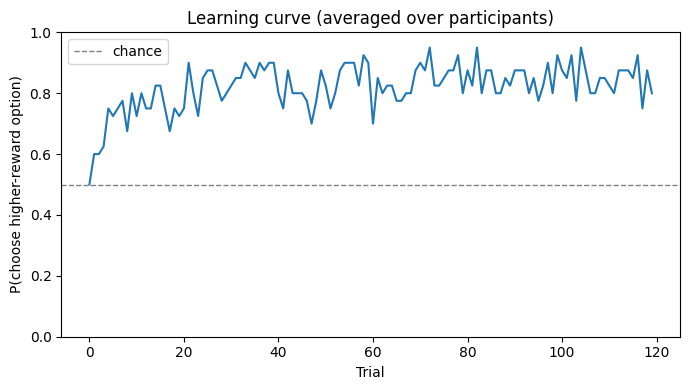

In [10]:
# Proportion choosing the higher-reward option (response == -1), averaged across
# participants at each trial.
data = data.copy()
data["chose_high_reward"] = (data["response"] == -1).astype(float)
learning_curve = data.groupby("trial_id")["chose_high_reward"].mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(learning_curve.index, learning_curve.values, color="C0")
ax.axhline(0.5, ls="--", color="gray", lw=1, label="chance")
ax.set_xlabel("Trial")
ax.set_ylabel("P(choose higher-reward option)")
ax.set_title("Learning curve (averaged over participants)")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

The curve climbs well above chance — the agents are learning. Next, the RT
distribution, split by which option was chosen.

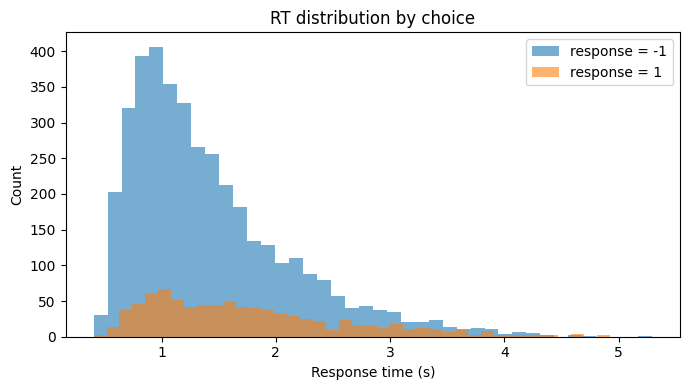

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
for label, color in [(-1, "C0"), (1, "C1")]:
    rts = data.loc[data["response"] == label, "rt"]
    ax.hist(rts, bins=40, alpha=0.6, color=color, label=f"response = {label}")
ax.set_xlabel("Response time (s)")
ax.set_ylabel("Count")
ax.set_title("RT distribution by choice")
ax.legend()
plt.tight_layout()
plt.show()

## 7. From simulation to inference

The point of simulating data is usually to *test inference* — can a model recover the
parameters that generated the data? That is HSSM's job. Two small steps connect the two
packages: **validating** the data, and **handing it off**.

### Validate the data

Before inference, it helps to check that a dataset has the structure HSSM expects
(required columns, a balanced and trial-ordered panel, valid response labels, no
stray missing values). `config.validate_data(...)` does this and returns a report you
can print, or turn into an error if something is wrong.

In [12]:
report = config.validate_data(data)
report.print()

# In a script you would typically guard with:
#   report.raise_for_errors()   # raises if the data is not inference-ready

RLSSM data validation report:
  [WARNING] extra_columns: data has extra columns not required by this model: ['chose_high_reward'].
  panel shape: participants=40, trials_per_participant=120


### Hand off to HSSM

HSSM consumes an `ssms.rl` model through a small **bridge**. The simulator side exposes
the model's structure as a plain dictionary, which is a useful thing to inspect:

In [13]:
bridge_dict = config.to_hssm_config_dict()

print("model_name      :", bridge_dict["model_name"])
print("decision_process:", bridge_dict["decision_process"])
print("list_params     :", bridge_dict["list_params"])
print("participant_contract:")
bridge_dict["participant_contract"]

model_name      : 2AB_RW_Angle
decision_process: angle
list_params     : ['rl_alpha', 'scaler', 'a', 'z', 't', 'theta']
participant_contract:


{'trial_params': ['rl_alpha', 'scaler'],
 'computed_outputs': ['v'],
 'response_field': 'response',
 'outcome_field': 'feedback',
 'input_fields': ['rl_alpha', 'scaler', 'response', 'feedback']}

On the HSSM side, you don't assemble any of this by hand. HSSM provides a factory that
takes the `ssms.rl` model (by preset name or config object) and builds a ready-to-fit
HSSM model. The code below is **illustrative** — it requires HSSM to be installed and is
not run as part of this simulator tutorial:

```python
import hssm

# Build an HSSM model directly from the ssms.rl model.
hssm_config = hssm.rl.RLSSMConfig.from_ssms_model(config)   # or "2AB_RW_Angle"
model = hssm.RLSSM(data=data, model_config=hssm_config)

# ... then sample and inspect as usual:
# idata = model.sample()
```

A higher-level constructor — `hssm.RLSSM(data, model="2AB_RW_Angle")` — is planned but
not yet available, so for now use `from_ssms_model(...)`. For the full end-to-end
inference and parameter-recovery workflow, see the
[`ssms.rl` API reference](../api/rlssm.md).

## 8. Summary and next steps

You now know the whole basic arc:

- An **RLSSM** = a **learning process** + a **decision process (SSM)** + a **task
  environment**, simulated in an interleaved trial-by-trial loop.
- **Presets** (`rl.preset.list / info / get`) are the fastest way to a working model.
- A **`ModelConfig`** can be built by hand from the three pillars; `rl.Simulator`
  turns it (plus a `theta` of parameter values) into a balanced panel of behavioral
  data, for one or many participants.
- The data is a tidy DataFrame you can inspect, plot, **validate**, and **hand off to
  HSSM** for inference.

**Continue with the [advanced tutorial](rlssm_advanced_tutorial.ipynb)**, which covers:

- response labels vs. zero-based learning actions, and explicit `response_mapping`;
- alternative components: dual-learning-rate Rescorla–Wagner, Gaussian-reward bandits,
  the `TaskConfig` shorthand, and custom learning processes / task environments;
- the full rules for participant-wise parameters;
- posterior predictive simulation (`mode="ppc"`);
- data-validation failure modes and how to fix them;
- compiled models, the backend/gradient policy, and HSSM bridge internals.

See also the [`ssms.rl` API reference](../api/rlssm.md).